# Prediciting Heart Disease using Logistic Regression

#### In this notebook we will analysing the important features for prediciting heart disease and using a logistic regression model we will predict heart disease based on these features

In [1]:
# Load Required Libraries
from sklearn.metrics import classification_report, roc_auc_score, log_loss
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# Import training data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [3]:
train_df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

No missing values in the training data. Now we will visualise some of the features and determine their relationship with our target.

In [5]:
print("Age:",train_df["Age"].unique())
print("Sex:",train_df["Sex"].unique())
print("Chest pain type:",train_df["Chest pain type"].unique())
print("BP:",train_df["BP"].unique())
print("Cholesterol:",train_df["Cholesterol"].unique())
print("FBS over 120:",train_df["FBS over 120"].unique())
print("EKG results:",train_df["EKG results"].unique())
print("Max HR:",train_df["Max HR"].unique())
print("Exercise angina:",train_df["Exercise angina"].unique())
print("ST depression:",train_df["ST depression"].unique())
print("Slope of ST:",train_df["Slope of ST"].unique())
print("Number of vessels fluro:",train_df["Number of vessels fluro"].unique())
print("Thallium:",train_df["Thallium"].unique())

Age: [58 52 56 44 38 59 60 48 41 42 53 50 65 46 62 57 54 66 51 55 43 71 63 61
 35 49 47 67 64 45 40 70 69 37 76 34 68 39 74 77 29 75]
Sex: [1 0]
Chest pain type: [4 1 2 3]
BP: [152 125 160 134 140 138 130 120 150 108 110 178 124  94 112 128 118 100
 105 172 180 145 132 142 122 135 136 126 106 101 115 156 170 146 192 102
 117 148 104 200 165 129 174 123 144 158 133 103 147 155 149 109 168 111
 154 127 114 116 175 141 131 162  99  96  95 184]
Cholesterol: [239 325 188 229 234 283 246 245 212 197 230 263 244 231 274 282 199 226
 204 185 177 250 211 303 201 266 256 219 222 249 235 295 258 271 304 277
 203 228 269 208 254 268 206 299 221 196 240 298 288 265 198 270 243 309
 233 330 255 315 261 294 223 214 273 286 267 260 236 289 252 275 302 224
 305 218 340 248 308 300 149 209 225 213 207 180 192 327 232 200 341 227
 322 220 311 210 172 247 360 306 318 215 335 205 178 182 242 168 564 353
 195 253 407 276 313 354 257 307 409 217 175 290 321 184 174 281 319 186
 417 193 293 164 166 160 216 18

The continuous features are: 
1. Age
2. BP
3. Cholesterol
4. Max HR
5. ST depression
   
The categorical features are:
1. Sex
2. Chest pain type
3. FBS over 120
4. EKG results
5. Exercise angina
6. Slope of ST
7. Number of vessels fluro
8. Thallium

## Visualisations

##### We will first peform some visualisations of Heart Disease by the continueoius features & look at the Correlations

/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])


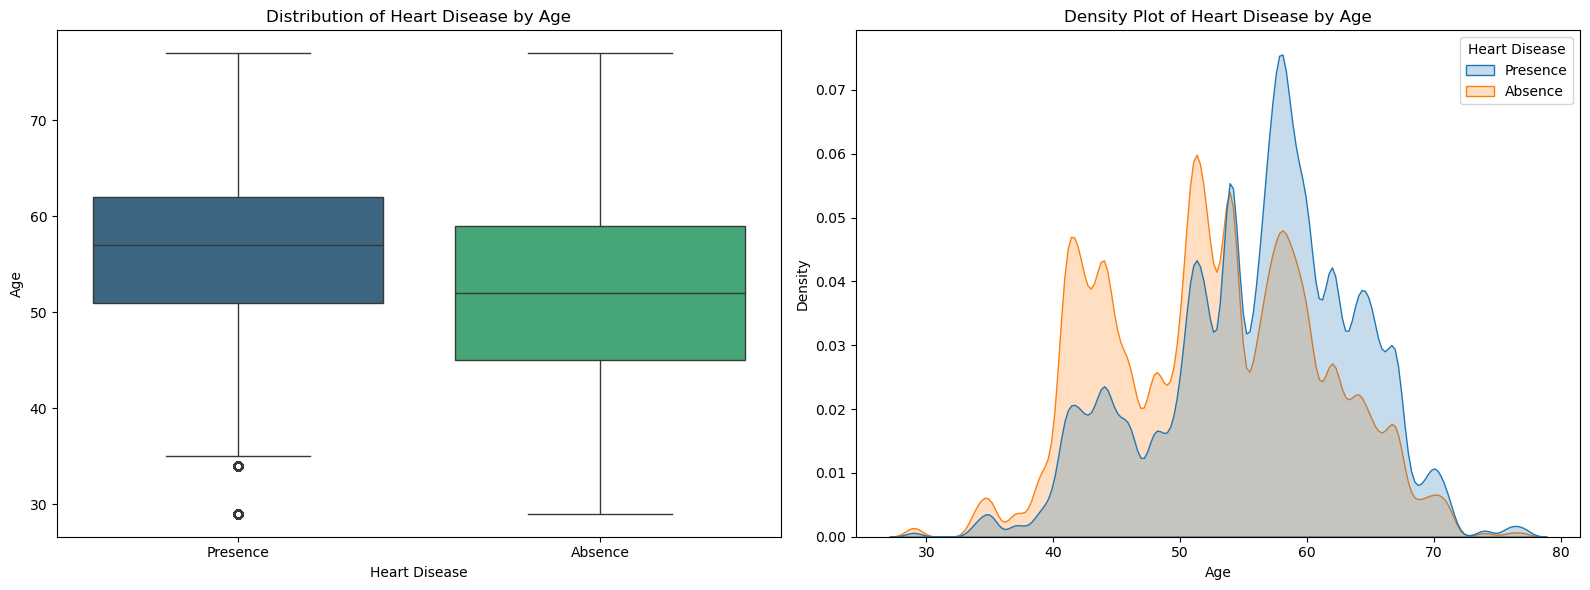

Point-Biserial Correlation: 0.2121
------------------------------


/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])


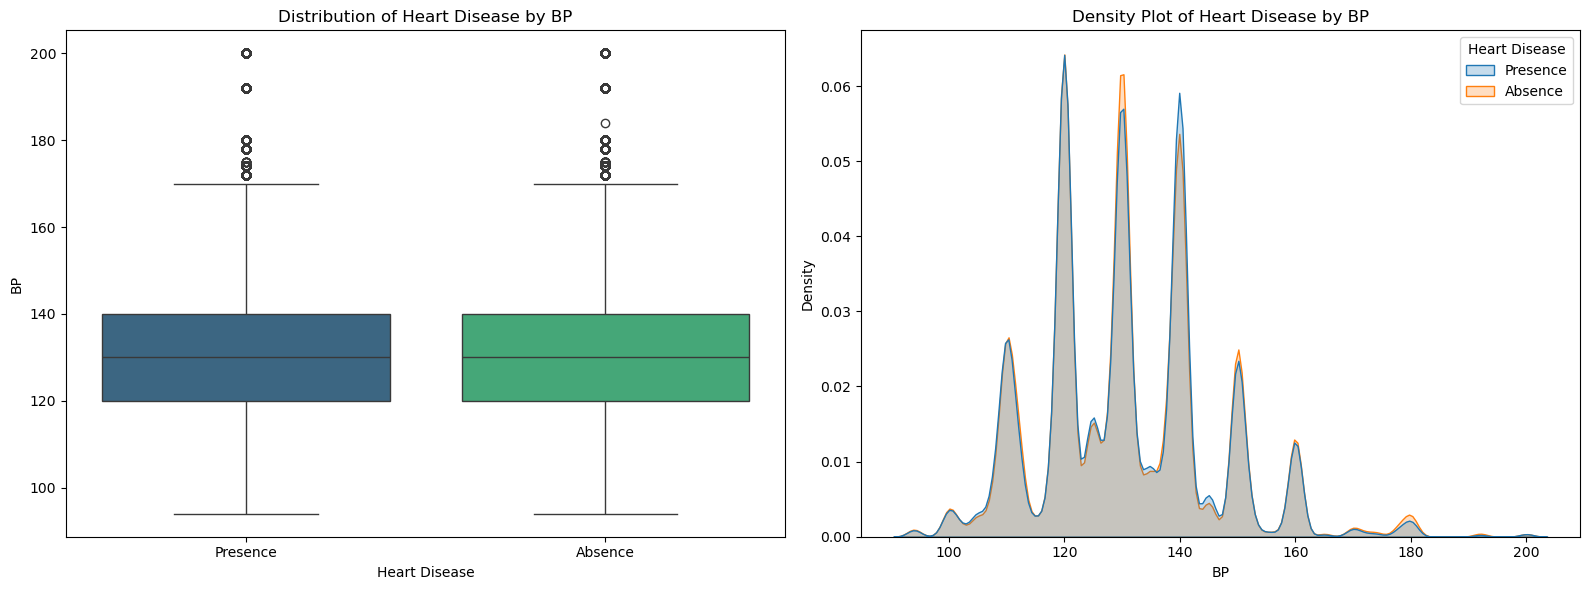

Point-Biserial Correlation: -0.0052
------------------------------


/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])


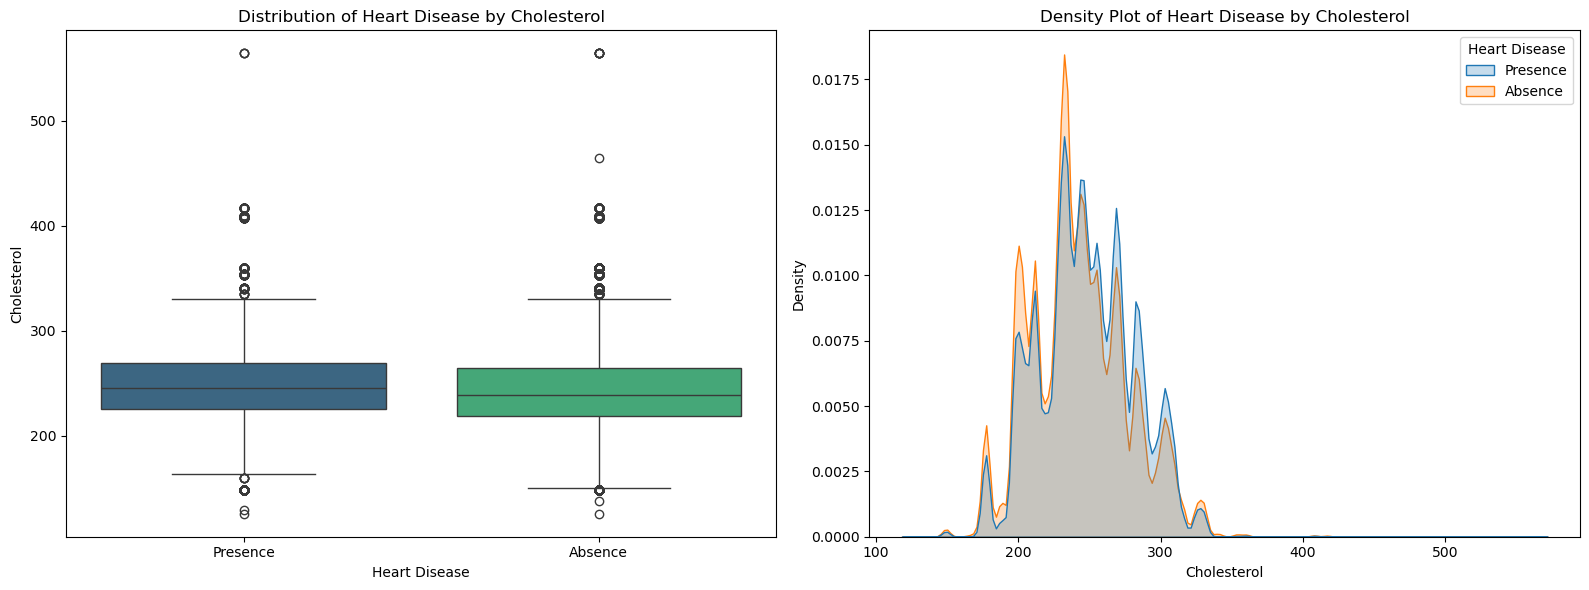

Point-Biserial Correlation: 0.0828
------------------------------


/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])


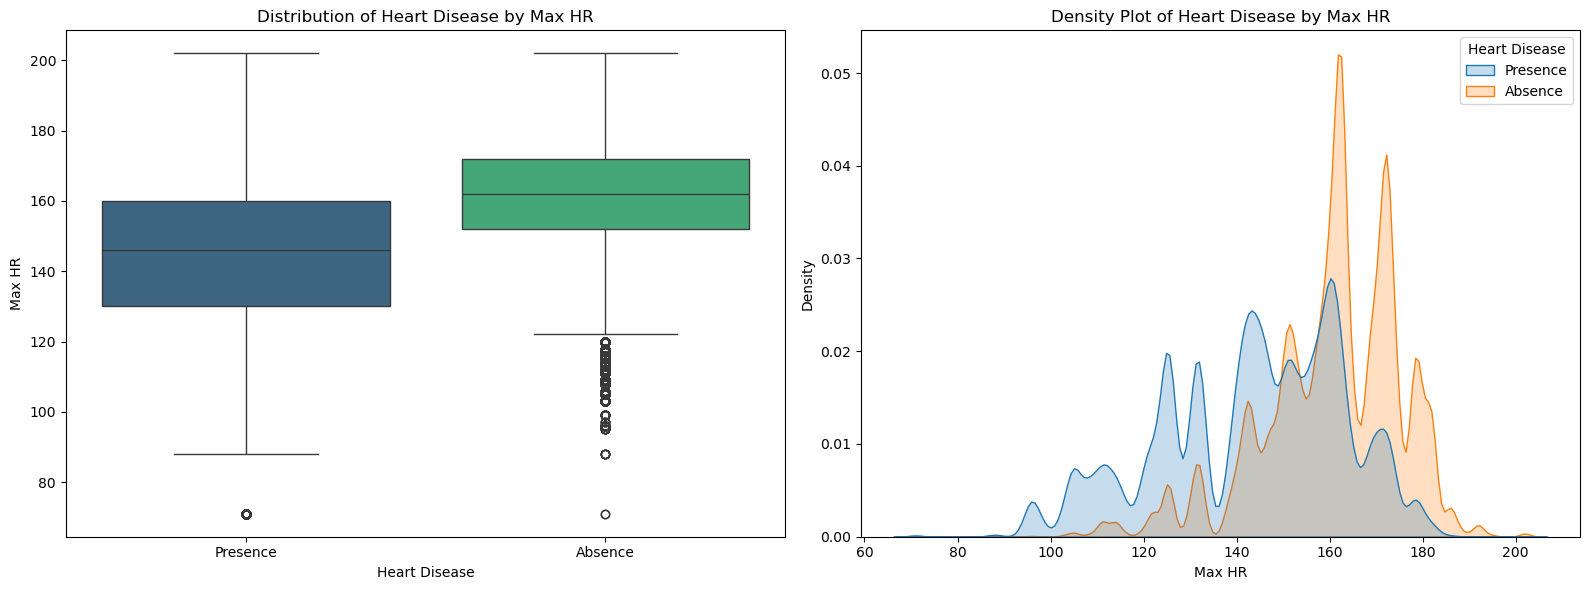

Point-Biserial Correlation: -0.4410
------------------------------


/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
/var/folders/fk/ln6xbd8n2dq25_4_pkjxwjyw0000gn/T/ipykernel_26350/4019310073.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])


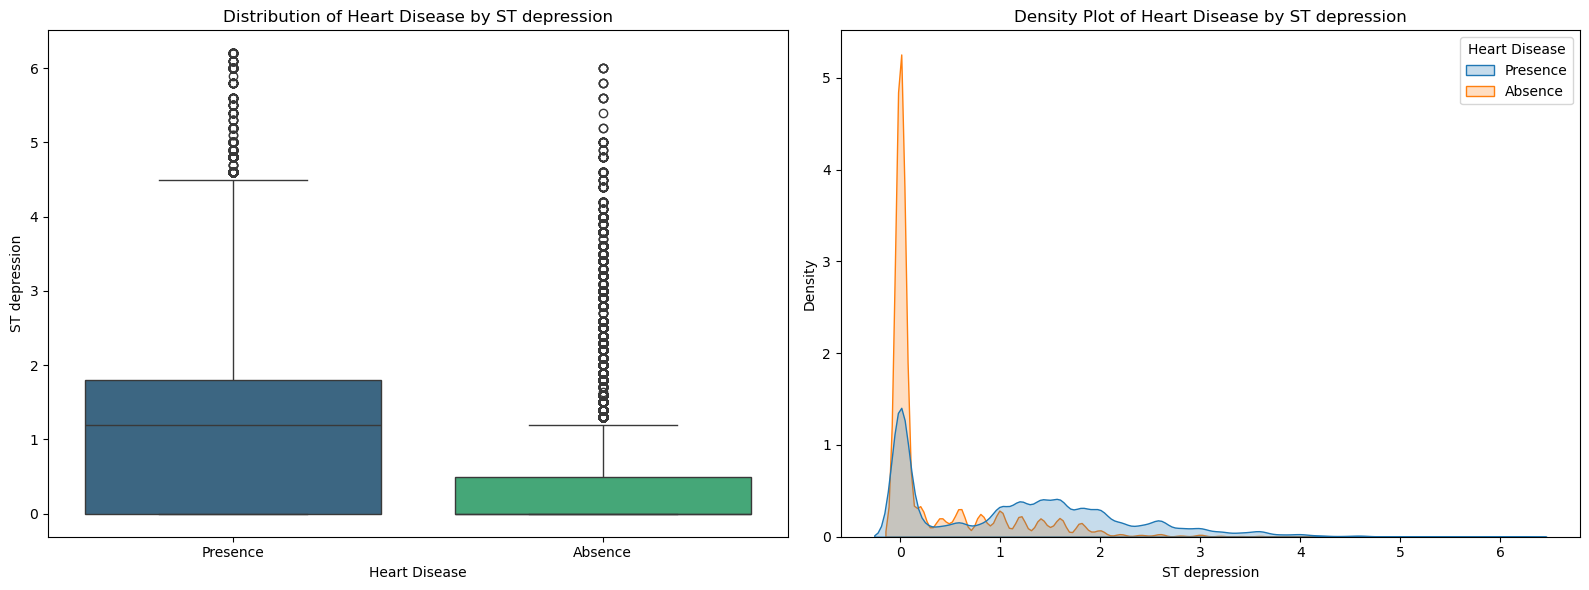

Point-Biserial Correlation: 0.4306
------------------------------


In [6]:
continuous_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

for col in continuous_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.boxplot(x='Heart Disease', y=col, data=train_df, palette='viridis', ax=axes[0])
    axes[0].set_title(f'Distribution of Heart Disease by {col}')

    sns.kdeplot(data=train_df, x=col, hue='Heart Disease', shade=True, common_norm=False, ax=axes[1])
    axes[1].set_title(f'Density Plot of Heart Disease by {col}')

    # Rotate x-labels to 0 for readability
    axes[0].tick_params(axis='x', rotation=0)
    axes[1].tick_params(axis='x', rotation=0)

    # Clean up layout and show the combined figure
    plt.tight_layout()
    plt.show()

    # Statistical Test (Point-Biserial Correlation)
    corr, _ = pointbiserialr(train_df['Heart Disease'].map({"Presence": 1, "Absence": 0}), train_df[col])
    print(f"Point-Biserial Correlation: {corr:.4f}")

    print("-" * 30)

Based on the visualisations of the cts features above and the point-biserial correlation, we will keep features:
1. ST depression
2. Max HR
3. Age

##### We will now peform some visualisations of Heart Disease by the categorical features

Firstly we will define Cramer's V function for determeing statistical significance of the categorical features.

Formula: sqrt( (chi2/n) / min(cols-1, rows-1) )

In [7]:
def calculate_cramers_v(contingency_table):
    """ Calculate Cramer's V for a contingency table. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, c = contingency_table.shape
    
    return np.sqrt(phi2 / min(r - 1, c - 1))

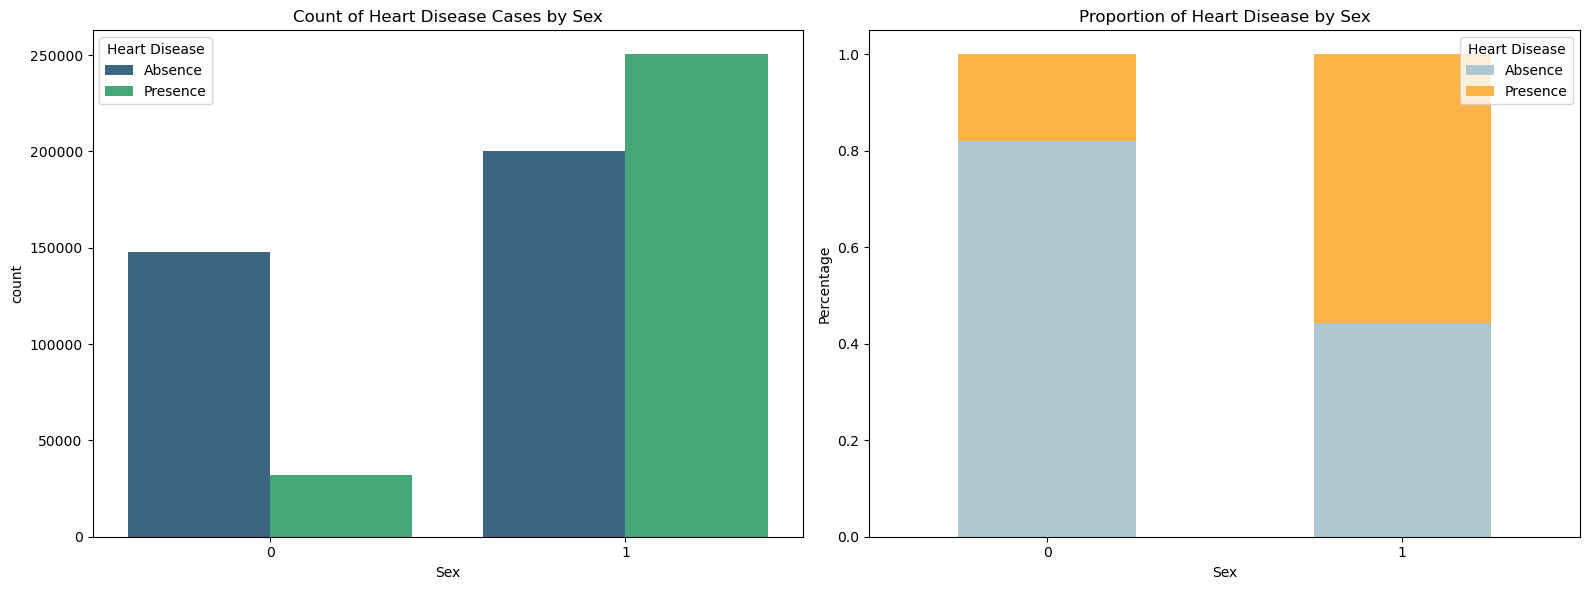

Feature: Sex
Chi-Square Statistic: 73878.2225
------------------------------


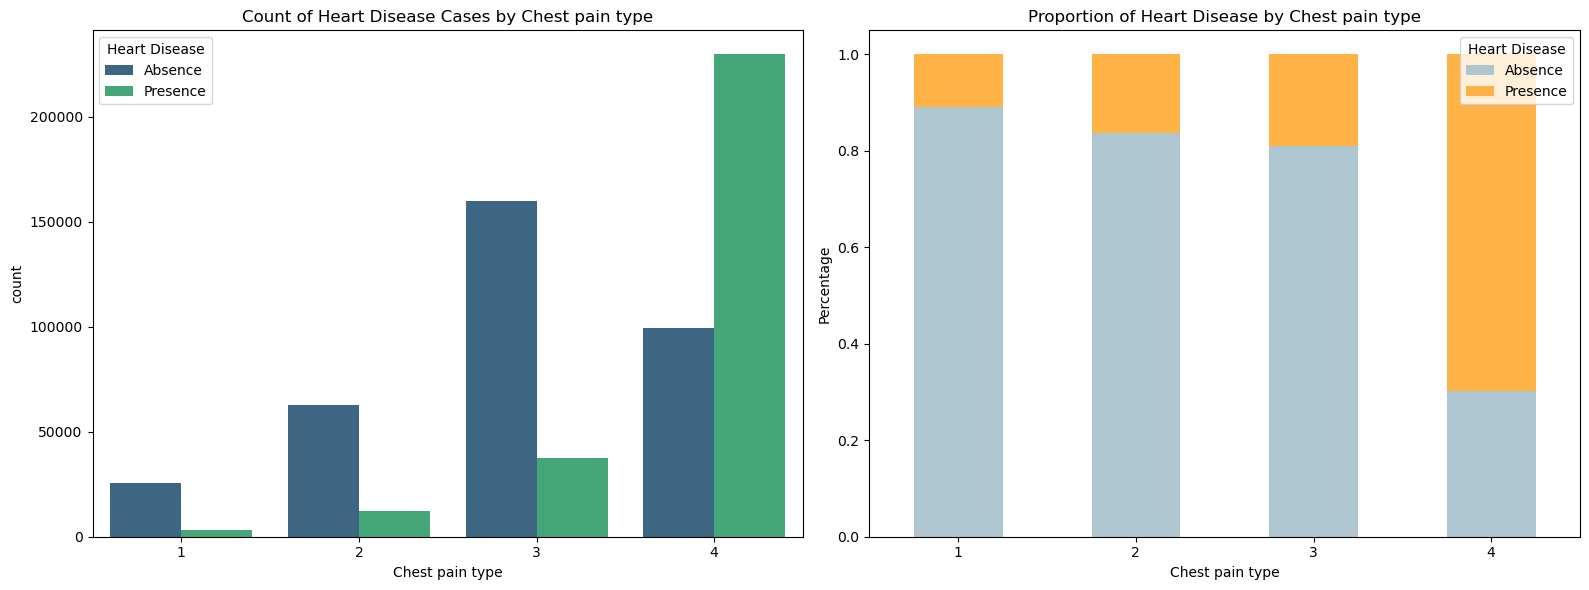

Feature: Chest pain type
Chi-Square Statistic: 173770.6617
------------------------------


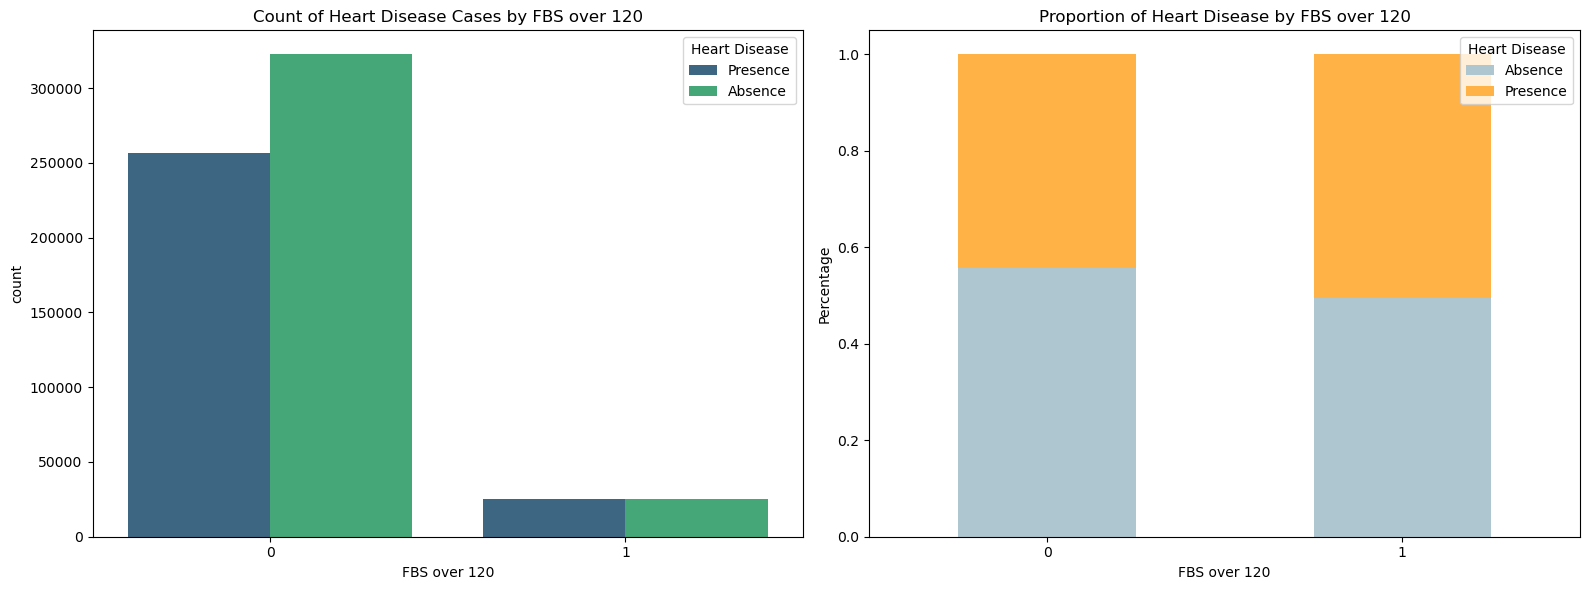

Feature: FBS over 120
Chi-Square Statistic: 709.7382
------------------------------


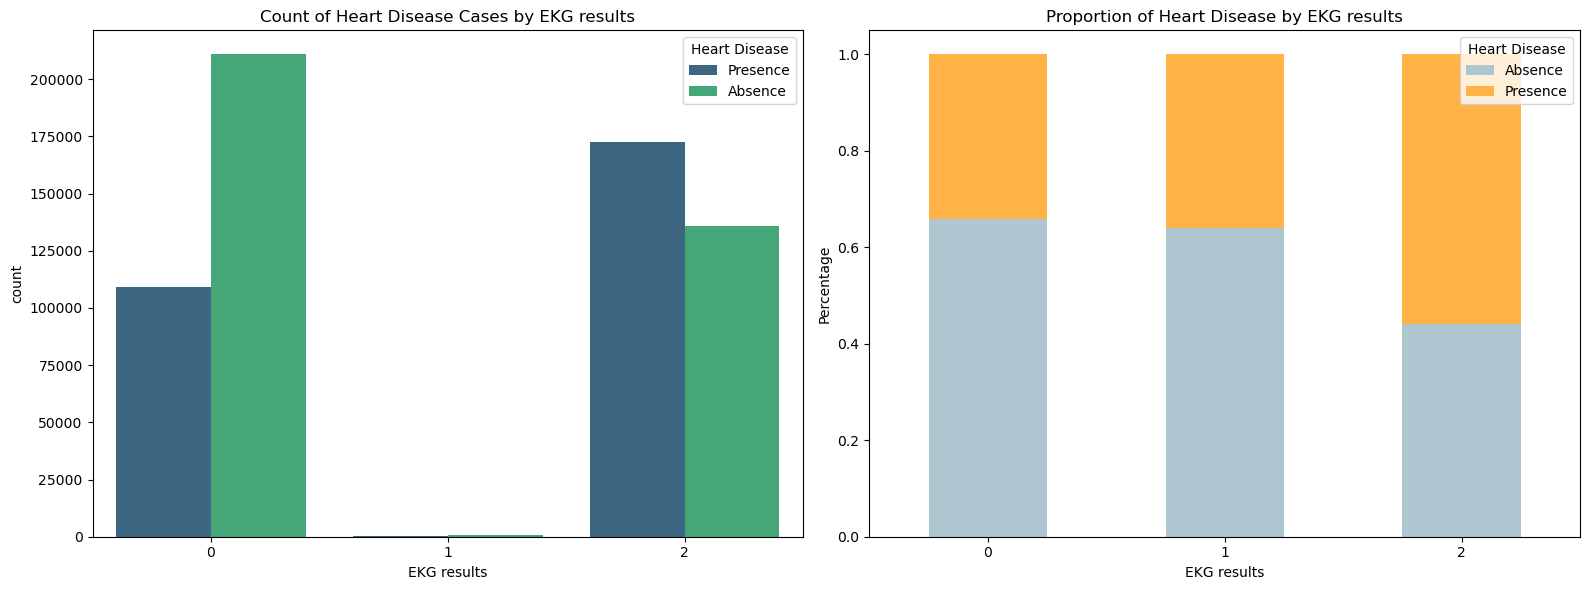

Feature: EKG results
Chi-Square Statistic: 30248.4162
------------------------------


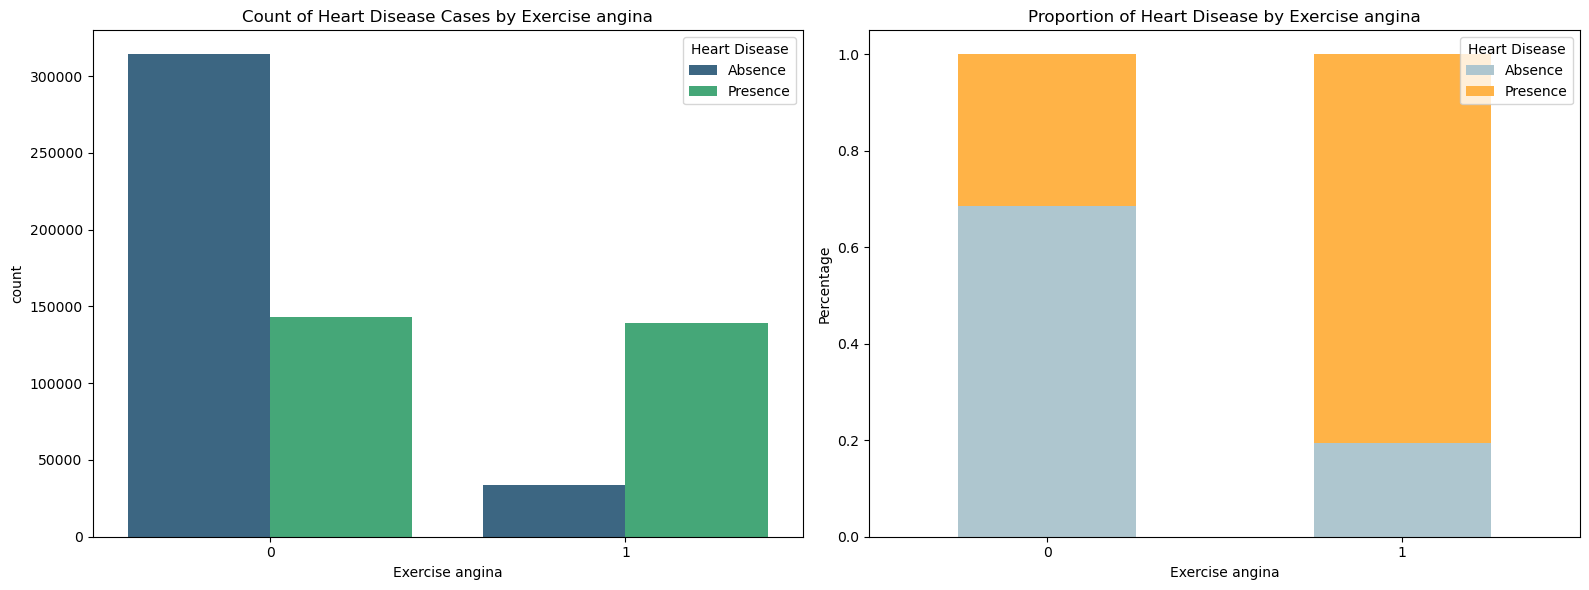

Feature: Exercise angina
Chi-Square Statistic: 123001.4483
------------------------------


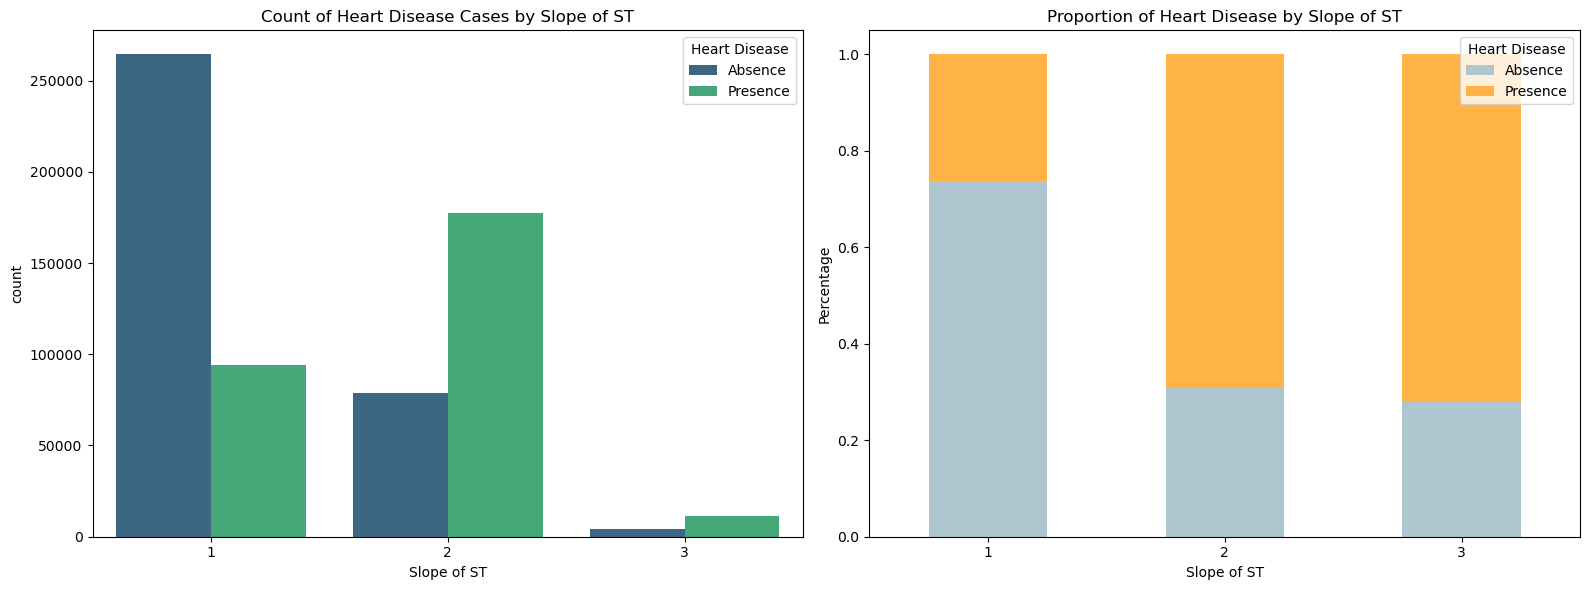

Feature: Slope of ST
Chi-Square Statistic: 116357.5794
------------------------------


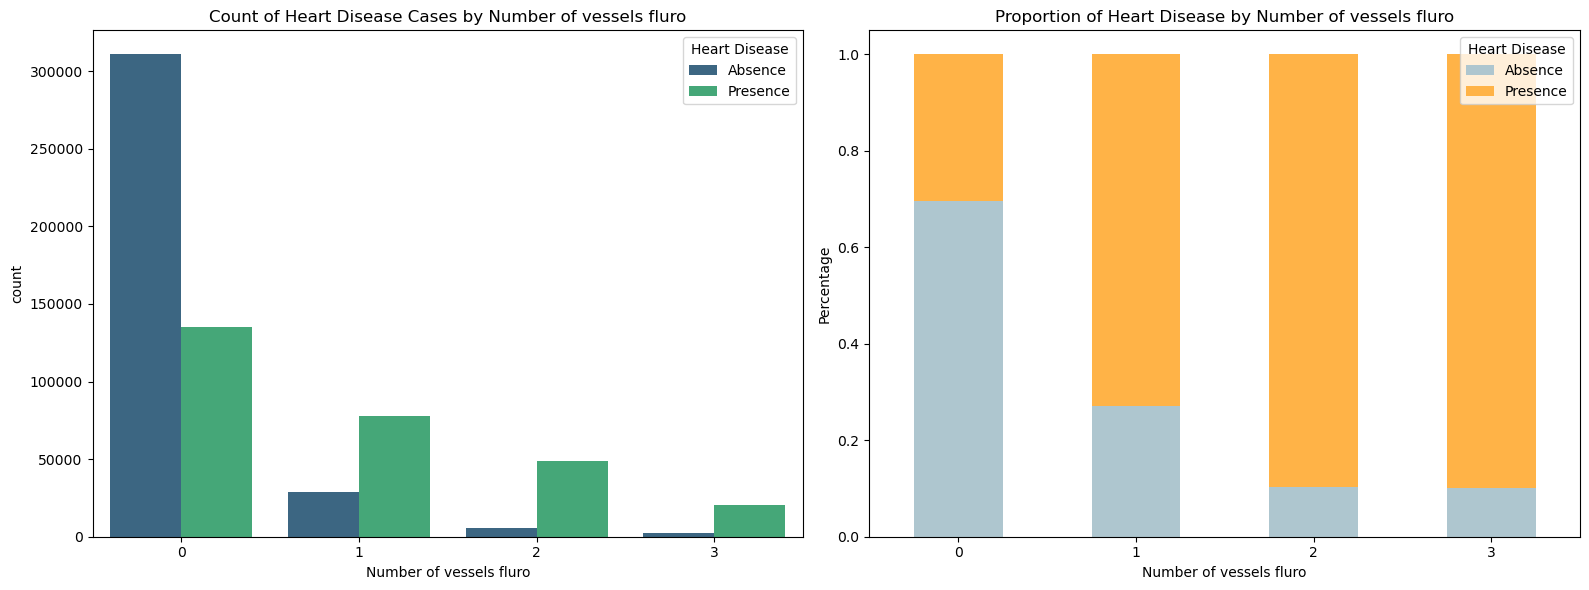

Feature: Number of vessels fluro
Chi-Square Statistic: 135190.5182
------------------------------


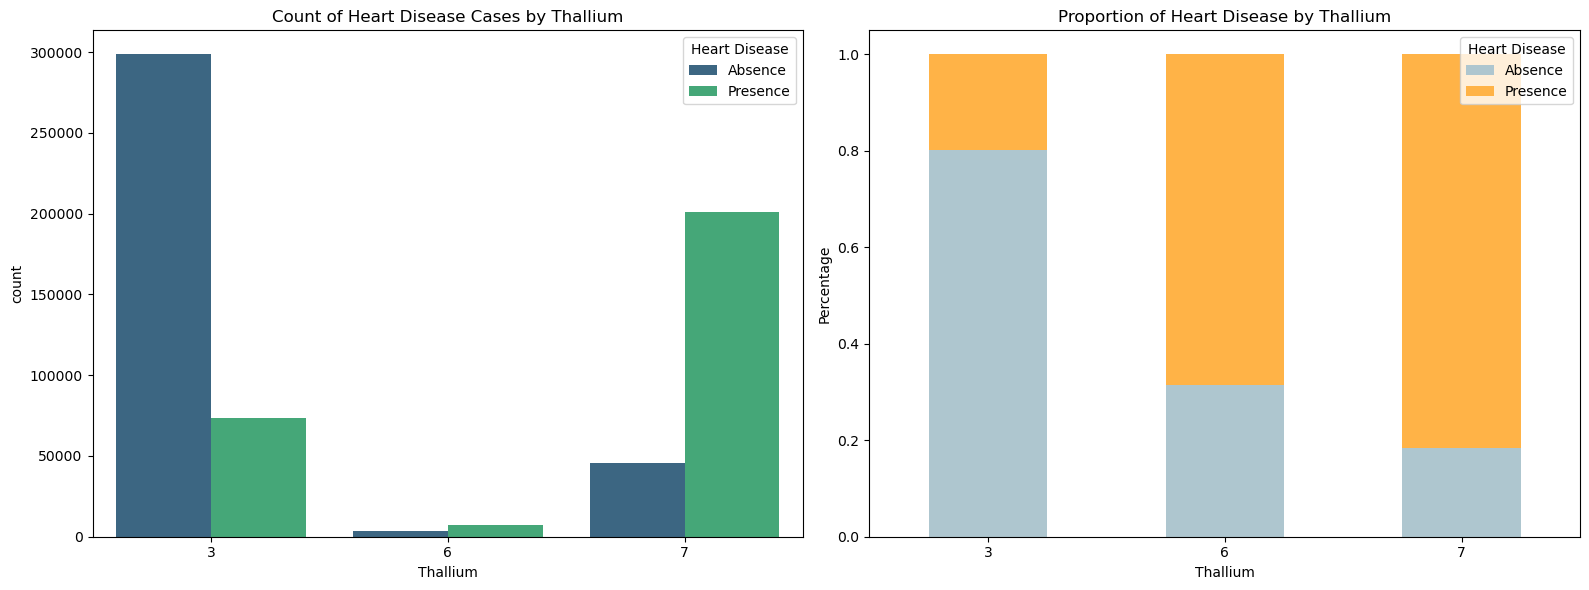

Feature: Thallium
Chi-Square Statistic: 231215.6918
------------------------------
                   Feature  Cramers_V
7                 Thallium   0.536543
6  Number of vessels fluro   0.534748
1          Chest pain type   0.523288
5              Slope of ST   0.422474
3              EKG results   0.199975
0                      Sex   0.000000
2             FBS over 120   0.000000
4          Exercise angina   0.000000


In [8]:
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                        'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
results = []

for col in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.countplot(data=train_df, x=col, hue='Heart Disease', palette='viridis', ax=axes[0])
    axes[0].set_title(f'Count of Heart Disease Cases by {col}')
    
    # Create the cross-tabulation for the proportions
    cross_tab = pd.crosstab(train_df[col], train_df['Heart Disease'], normalize='index')
    v_score = calculate_cramers_v(cross_tab)
    results.append({'Feature': col, 'Cramers_V': v_score})
    
    # Plot the Stacked Bar Chart on the second axis (axes[1])
    cross_tab.plot(kind='bar', stacked=True, color=['#aec6cf', '#ffb347'], ax=axes[1])
    axes[1].set_title(f'Proportion of Heart Disease by {col}')
    axes[1].set_ylabel('Percentage')
    axes[1].legend(title='Heart Disease', loc='upper right')
    
    # Rotate x-labels to 0 for readability
    axes[1].tick_params(axis='x', rotation=0)

    # Clean up layout and show the combined figure
    plt.tight_layout()
    plt.show()
    
    # Statistical Test (Chi-Square)
    contingency_table = pd.crosstab(train_df[col], train_df['Heart Disease'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"Feature: {col}")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print("-" * 30)

print(pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False))

Based on both the visualisations and the Cramers_V we will use the following categorical features:
1. Thallium
2. Number of vessels fluro
3. Chest pain type
4. Slope of ST
5. EKG results
6. Sex
7. Exercise angina

#### We will now remove the features: BP, Cholesterol, FBS over 120

In [9]:
drop_cols = ["BP", "Cholesterol", "FBS over 120"]
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [10]:
train_df.head()

,id,Age,Sex,Chest pain type,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,2,125,1,3.8,2,3,3,Presence


### Multicollinearity

We now want to check for multicollinearity amongst the categorical variables. To do this we will use a heatmap and comapre the Cramer V score amongst the features.

In [11]:
def cramers_v_multicoll(x, y):
    """ Calculate Cramer's V for two categorical columns. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

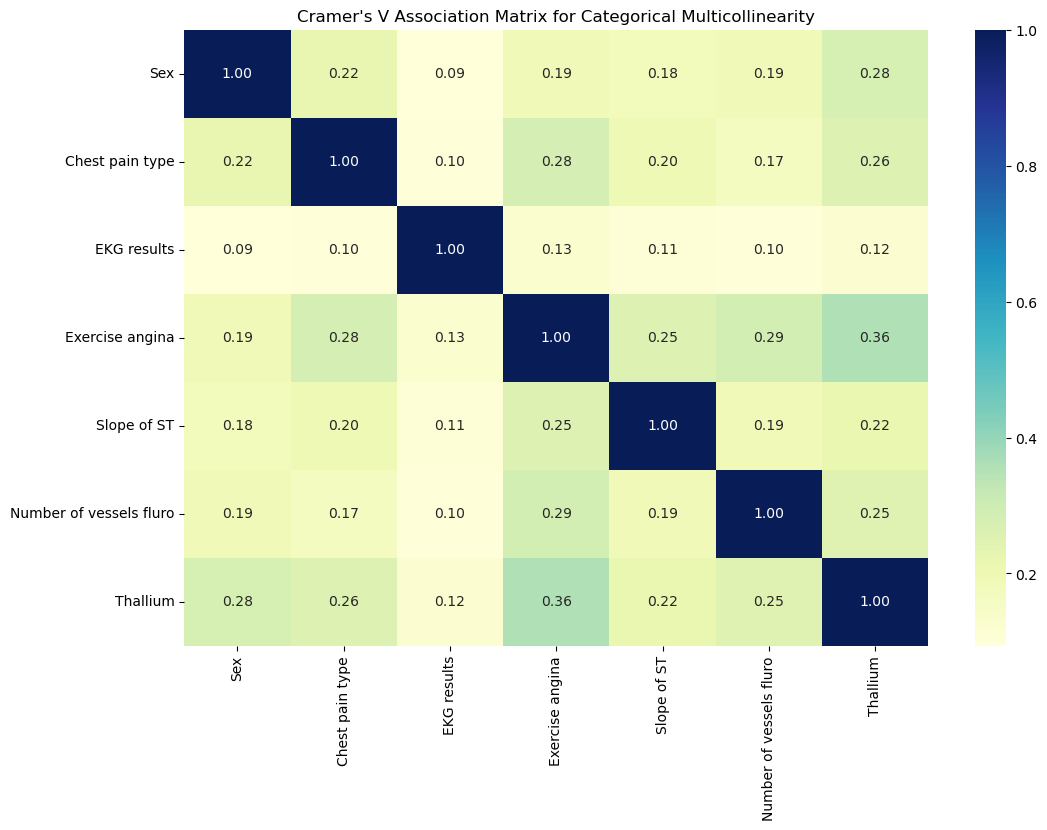

In [12]:
categorical_features = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 
                        'Slope of ST', 'Number of vessels fluro', 'Thallium']

v_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features)

# Fill the matrix
for col_1 in categorical_features:
    for col_2 in categorical_features:
        v_matrix.loc[col_1, col_2] = cramers_v_multicoll(train_df[col_1], train_df[col_2])

# Convert to float for plotting
v_matrix = v_matrix.astype(float)

# Plot as a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Cramer's V Association Matrix for Categorical Multicollinearity")
plt.show()

For the categorical features there doesn't appear to be any strong indicators of high multicollinearity. We now perform the same procedure using standard correlation for the continuous features

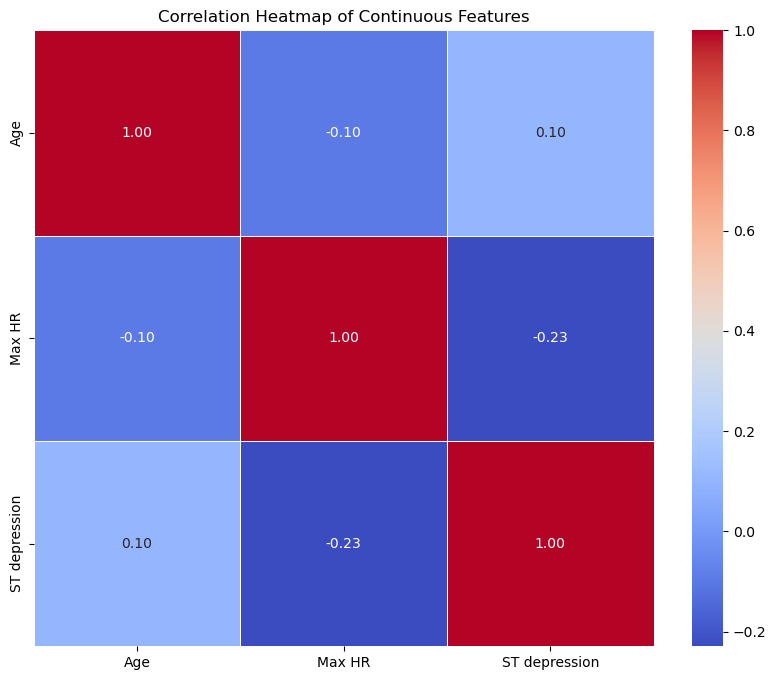

In [13]:
continuous_features = ["Age", "Max HR", "ST depression"]

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[continuous_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Continuous Features')
plt.show()

Overall no signs of multicollinearity amongst the continuous features, therefore we will keep all of the features

### Preprocessing

In [14]:
X = train_df.drop('Heart Disease', axis=1)
y = train_df['Heart Disease'].map({"Presence": 1, "Absence": 0})

numeric_features = ['Age', 'Max HR', 'ST depression']
categorical_features = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina',
                        'Slope of ST', 'Number of vessels fluro', 'Thallium']

# Create a preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create the full Pipeline, combining the preprocessor with a classifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

### StratifiedKFold Cross Validation

In [15]:
# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation on X_train & y_train
cross_val = cross_val_score(clf_pipeline, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"Mean ROC-AUC: {cross_val.mean():.4f}")
print(f"Standard Deviation: {cross_val.std():.4f}")

Mean ROC-AUC: 0.9527
Standard Deviation: 0.0002


### Train the model and Predictions

In [16]:
# Training
clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)  # Predictions (0 or 1)
y_prob = clf_pipeline.predict_proba(X_test)[:, 1]  # Probabilities (needed for AUC)

print("Classification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)  # Calculate ROC-AUC
print(f"ROC-AUC Score: {auc:.4f}")  

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    121444
           1       0.88      0.86      0.87     99056

    accuracy                           0.88    220500
   macro avg       0.88      0.88      0.88    220500
weighted avg       0.88      0.88      0.88    220500

ROC-AUC Score: 0.9528


### Predictions & Submission File for test.csv

In [17]:
test_pred = clf_pipeline.predict_proba(test_df)[:, 1] 

# Save predictions with id
submission = pd.DataFrame({
    "id": pd.read_csv("test.csv")["id"],
    "Heart Disease": test_pred})

submission.to_csv("submission.csv", index=False)